# The full width half maximum contains information about the correlation legnth


In [1]:
import sys

sys.path.append("../../src")
import numpy as np
from common_imports import *

In [2]:
ns = [1,2]
PP_corrs = []
for n in ns:
    folder = "data/"
    filename = f"data_Pn_corr_n{n}_rmax100.npz"
    path = folder+filename

    data = np.load(path, allow_pickle=True)
    n, r_max, r, PP, P, PP_corr = data["n"], data["r_max"], data["r"], data["PP"], data["P"], data["PP_corr"]
    PP_corrs.append(PP_corr)
    
# taus = np.logspace(-2,2.5,50)
# rs= np.arange(-100,100)
# dat = np.load("data/PP_n1_4.npy")

In [4]:
from numpy.fft import fft, fftshift, fftfreq
def FT(dat):
    return fftshift(fft(dat))
s_kn = []
for P in PP_corrs:
    S_mat = []
    for pp in P:
        S_k = FT(pp)
        S_mat.append(S_k)
    s_kn.append(array(S_mat))
r = np.arange(-100,100)


In [5]:
k = fftshift(fftfreq(len(r),1))*2*pi

In [10]:
taus = np.load("data/data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['taus']

IndexError: list index out of range

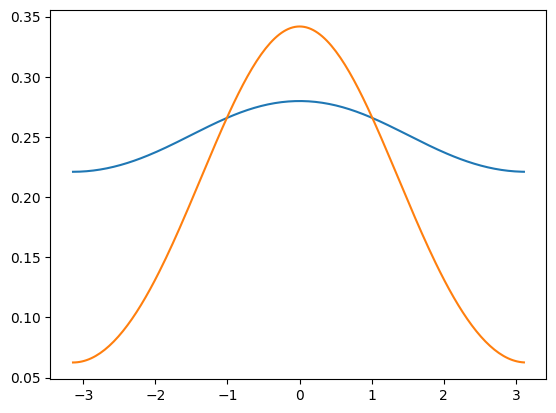

In [11]:
plt.figure()
j = 10
#title(taus[j])
plot(k,abs(s_kn[0][j]))
#show()
#plt.figure()
plot(k,abs(s_kn[1][j]))
plot(k,abs(s_kn[2][j]))
plot(k,abs(s_kn[3][j]))

#plt.figure()
#xlim(80,120)
show()

In [12]:
def fwhm(x, y):
    y = np.abs(y)
    half = np.max(y) / 2.0
    idx = np.where(np.diff(np.sign(y - half)))[0]
    if len(idx) >= 2:
        return x[idx[-1]] - x[idx[0]]
    return np.nan

ns = [1,2]

In [13]:
k_n = [ array([fwhm(k,abs(s_kn[n-1][j])) for j in range(len(taus))]) for n in ns]

In [14]:
k_n[0]

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan, 5.30929158, 4.80663676, 4.42964564, 4.11548638,
       3.86415896, 3.61283155, 3.36150414, 3.17300858, 2.98451302,
       2.79601746, 2.67035376, 2.4818582 , 2.35619449, 2.23053078,
       2.10486708, 1.97920337, 1.85353967, 1.72787596, 1.60221225,
       1.5393804 , 1.41371669, 1.35088484, 1.22522113, 1.16238928,
       1.09955743, 1.03672558, 0.97389372, 0.91106187, 0.84823002,
       0.78539816, 0.72256631, 0.65973446, 0.65973446, 0.5969026 ,
       0.53407075, 0.53407075, 0.4712389 , 0.40840704, 0.40840704,
       0.40840704, 0.34557519, 0.34557519, 0.28274334, 0.28274334,
       0.28274334, 0.21991149, 0.21991149, 0.21991149, 0.21991

[]

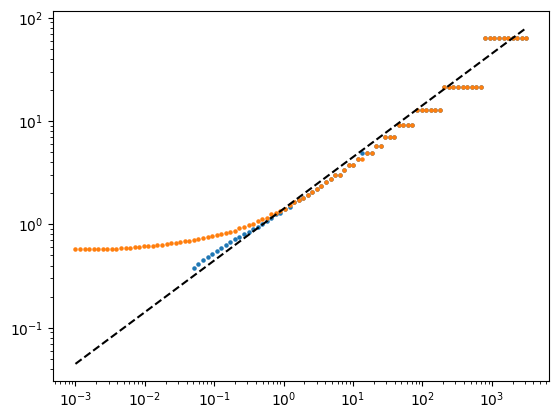

In [15]:
for kr in k_n[:4]:
    scatter(taus,1/(kr/2),s=5)
plot(taus,(sqrt(2*taus)),"--k") 
#xlim(10e-3,10e1)
loglog()

[]

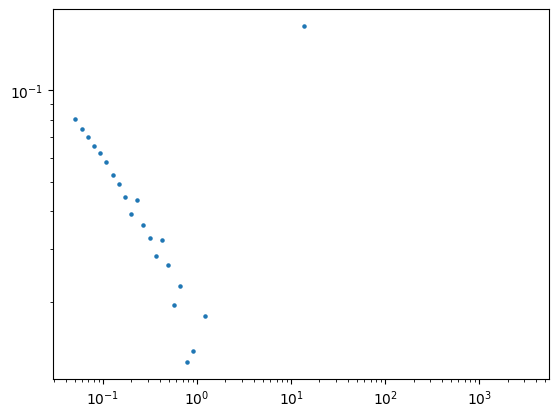

In [19]:

scatter(taus,abs(1/k_n[0]/2-1/(k_n[1])/2),s=5)

#xlim(10e-3,10e1)
loglog()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()